## Test rotation funcitons

Pending: 
- test new rotation function by itself: beamrotation_test_opt_fast in testrotation notebook

In [13]:
#%matplotlib widget
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import timeit
import importlib


import functions_rot as frot
import functions_beams as fbeams


from scipy.interpolate import RBFInterpolator

In [2]:
importlib.reload(frot)
importlib.reload(fbeams)

<module 'functions_beams' from '/home/evanetti/BEAMS/beams_code/functions_beams.py'>

In [3]:
# Settings
freq='70GHz' # '30GHz'   '70GHz', '143GHz'
check_time=False  #run Timing portion of notebook 

### Read beam

In [4]:
map_beam, v1c = fbeams.read_beam(freq, printtext=True)

nside=hp.get_nside(map_beam)
angdistR=fbeams.beam_radius(map_beam, v1c)
print('\nbeam dimension (rad) = ', angdistR )

Beam file:  beams_070_2247339.fits
Nside =  1024

Beam center:
- center pixel idx =  2247339
- center lonlat (phi,theta) =  (60.029296875, 39.98433353062975)
- center vector = [0.38277074 0.66376194 0.64257812]
Normalization factor =  0.9910121240031213
Normalized beam integral =  0.9999999999999998

beam dimension (rad) =  0.015248735030958454


l=0	 4pi*Cl=: 0.9999999999982307 	 Cl = 0.07957747154580688
l=1	 4pi*Cl=: 0.9999944116785752 	 Cl = 0.0795770268414585
l=2	 4pi*Cl=: 0.9999832351607869 	 Cl = 0.07957613744243222
l=3	 4pi*Cl=: 0.9999664706486635 	 Cl = 0.07957480336494574
l=4	 4pi*Cl=: 0.9999441184574973 	 Cl = 0.07957302463408922
max map_beam =  59100.12206855254 	max rad profile =  59910.23888714125


/home/evanetti/BEAMS/beams_code/functions_beams.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


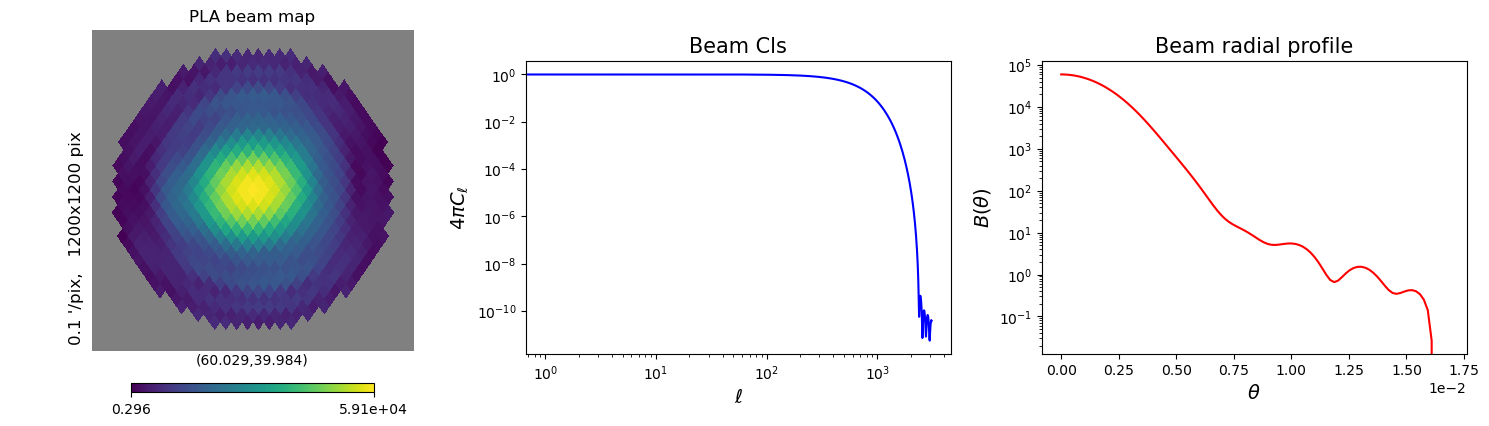

1

In [5]:
fbeams.plot_beam(map_beam, v1c)

## Define rotation

In [6]:
# Define destination position [keep for the entire notebook]
phic2, thetac2= 10., 50.   #destination coordinates
v2c=hp.pixelfunc.ang2vec(phic2, thetac2, lonlat=True) #checked that all vectors are distinct
print(f'Rotate to (phi2,theta2)=({phic2},{thetac2})')
print(f'ditection: v2={v2c}')

Rotate to (phi2,theta2)=(10.0,50.0)
ditection: v2=[0.63302222 0.1116189  0.76604444]


In [7]:
## get rotation quantities
angdistR=fbeams.beam_radius(map_beam, v1c) # angdist: distance from beam center to include all pixels
print('beam angular radius = ',angdistR, ' radians\t = ', np.rad2deg(angdistR), 'º'  )
v1, beam1 = frot.beam_grid(map_beam, v1c, angdistR) #interpolation grid at original beam: positions and values
interpolator0 = RBFInterpolator(v1.T, beam1, kernel='cubic') #method 2: build interpolator at original beam position  
#options: 'thin_plate_spline' or 'multiquadric', 'cubic' (linear and quintic don't work well)

beam angular radius =  0.015248735030958454  radians	 =  0.8736881601872101 º
724 pixels used for interpolation


In [8]:
R1=frot.get_R1(v1c)

### Compare rotation functions:

Result: Cls rel diff $<10^{-9}$ // map diff $<10^{-5}$ //moments rel diff $<10^{-8}$


In [9]:
if check_time==True: 
    %timeit beamrotation_test(v1c, v2c, v1, beam1, nside, angdistR)
    %timeit beamrotation_test_opt(v1c, v2c, interpolator0, nside, angdistR)

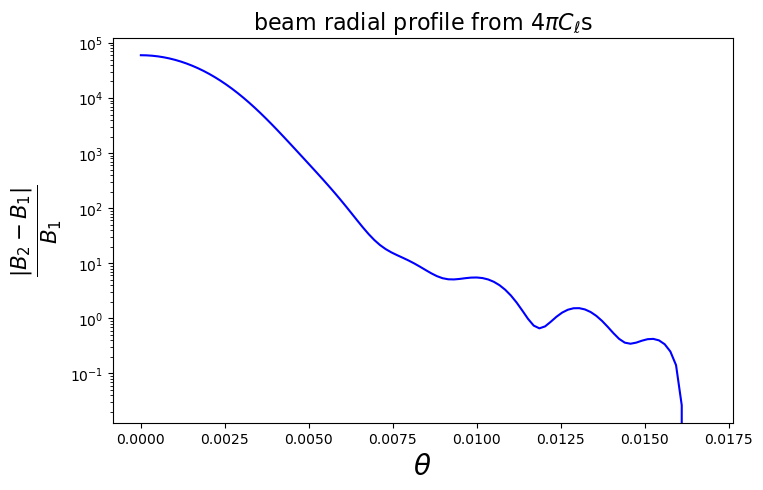

In [10]:
importlib.reload(fbeams)
x,y=fbeams.beam_rad_profile(map_beam, angdistR, plot=True)

Max value: 58606.43745489069 original map	58606.43745291861 rotated map	 difference = -1.97208282770589e-06	rel difference = -3.364959402665961e-09%

1-order moment: In1=1.0000249576574531	In2=1.0000249560658256	difference = 1.5916274964666854e-09	rel difference = 1.5915877741642113e-07 %
2-order moment: In1=29813.043380860803	In2=29813.043377300608	difference = 3.560195182217285e-06	rel difference = 1.1941736832217665e-08 %
3-order moment: In1=1181851618.5568857	In2=1181851618.3977587	difference = 0.15912699699401855	rel difference = 1.3464211115463252e-08 %
4-order moment: In1=52549228263983.59	In2=52549228255540.81	difference = 8442.78125	rel difference = 1.606642291222105e-08 %
5-order moment: In1=2.488992022062616e+18	In2=2.488992021591065e+18	difference = 471550976.0	rel difference = 1.894545952016463e-08 %

Cls factional difference at l=0 3.1831712438247657e-09


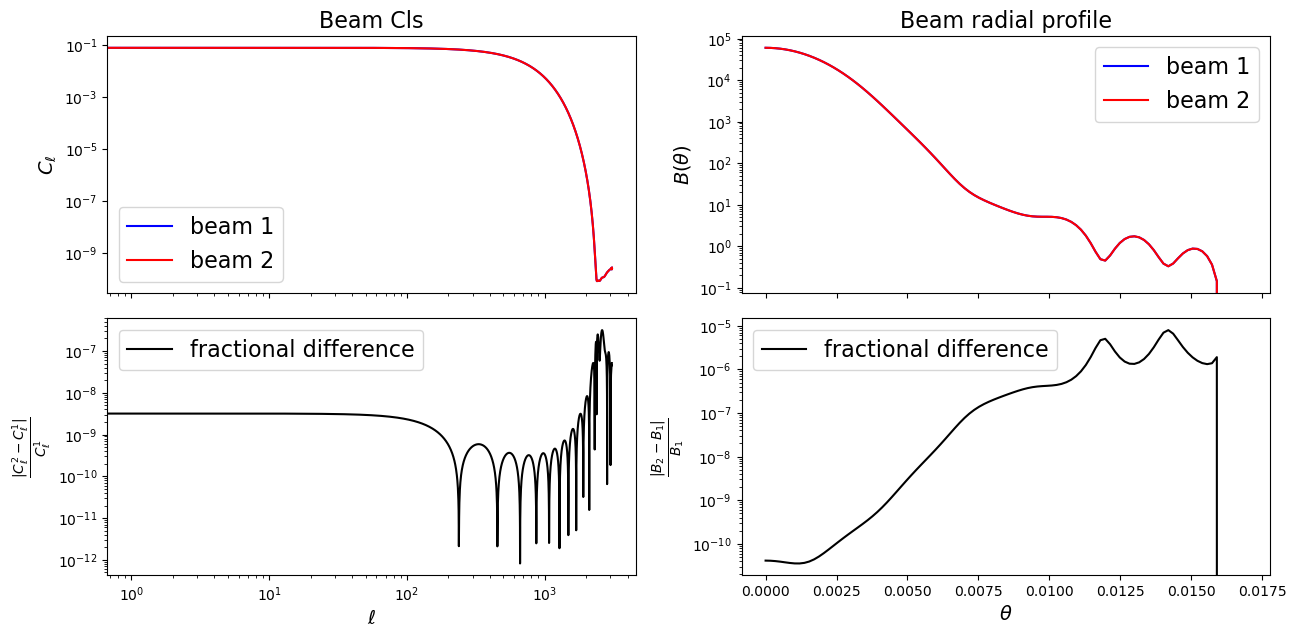

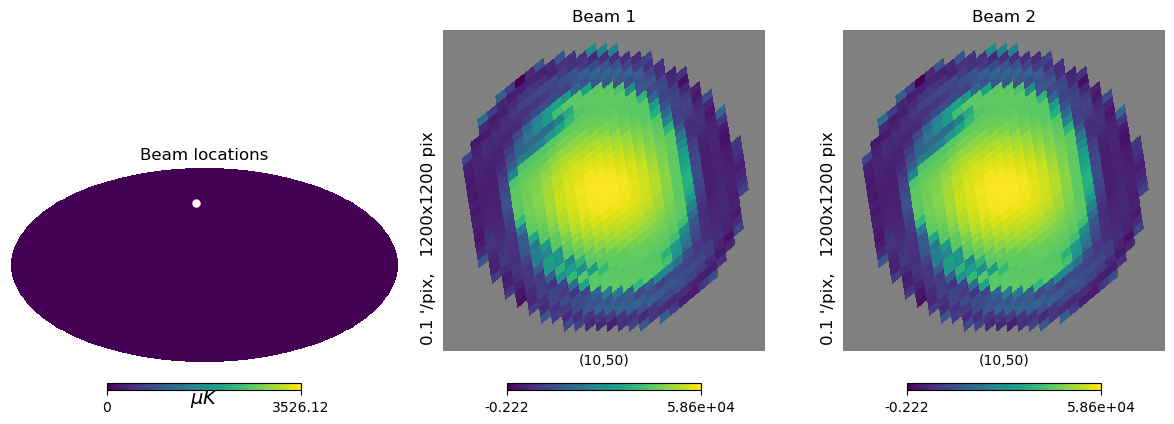

difference map (min,max) =  -3.9504993765149266e-06 3.093737177550793e-08
relative difference map (min,max) =  -0.0020251861630242556 % , 0.001121740915964764%


<Figure size 500x500 with 0 Axes>

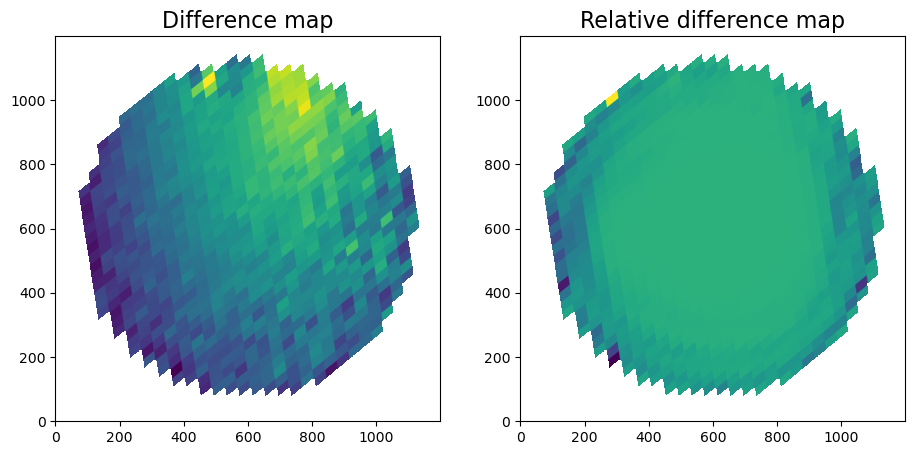

In [11]:
## Compare 2 rotation methods:
map_func1= frot.beamrotation_test(v1c, v2c, v1, beam1, nside, angdistR)
map_func2= frot.beamrotation_test_opt(v1c, v2c, interpolator0, nside, angdistR)
x=fbeams.compare_beams(v2c, v2c, map_func1, map_func2)

### Test rotation to a random position

Test 2: compare original with rotated beam (for optimized function)

Ideas: compute percent difference in beam peak on the entire map: build interpolator as usual, then rotate and interpolate just one pixel --> see if there is theta dependence on the map

Max value: 59100.12206855254 original map	58606.43745291861 rotated map	 difference = -493.68461563393066	rel difference = -0.8353360337585878%

1-order moment: In1=1.0000000000000004	In2=1.0000249560658256	difference = -2.4956065825199047e-05	rel difference = -0.002495606582519904 %
2-order moment: In1=29821.232678181823	In2=29813.043377300608	difference = 8.189300881214876	rel difference = 0.027461309093391145 %
3-order moment: In1=1182808252.5932684	In2=1181851618.3977587	difference = 956634.1955096722	rel difference = 0.08087821448762156 %
4-order moment: In1=52622356259535.375	In2=52549228255540.81	difference = 73128003994.5625	rel difference = 0.13896755902356886 %
5-order moment: In1=2.4937883453705687e+18	In2=2.488992021591065e+18	difference = 4796323779503616.0	rel difference = 0.19233082825202225 %

Cls factional difference at l=0 4.991536945895937e-05


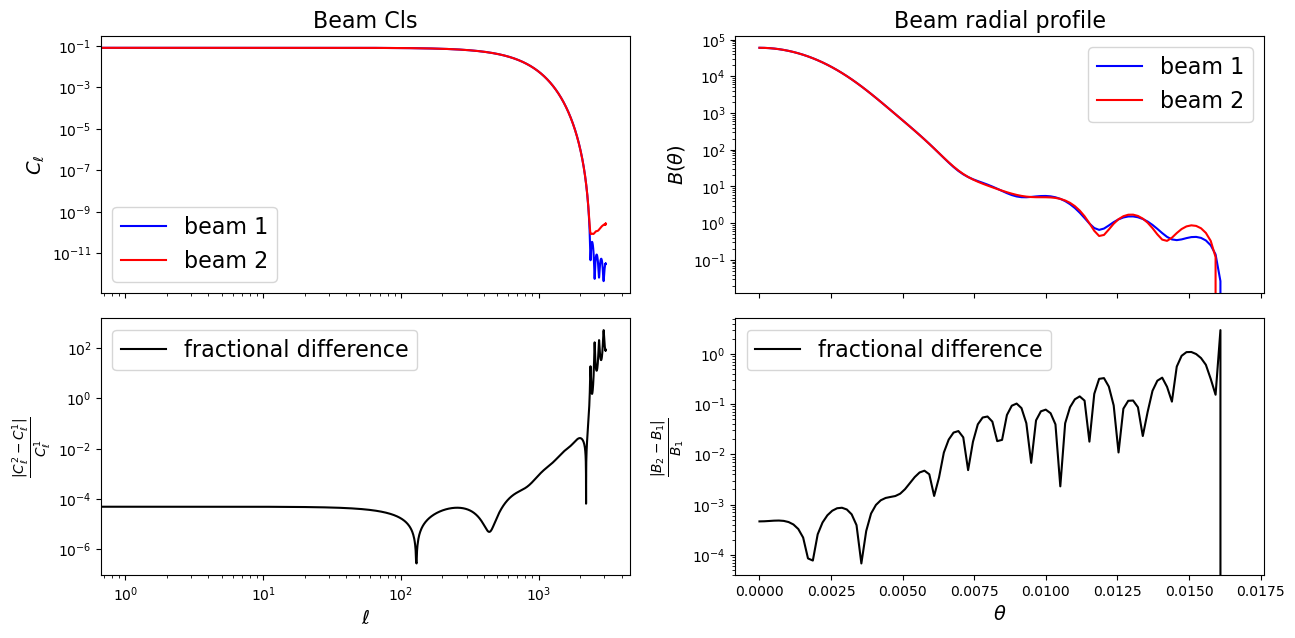

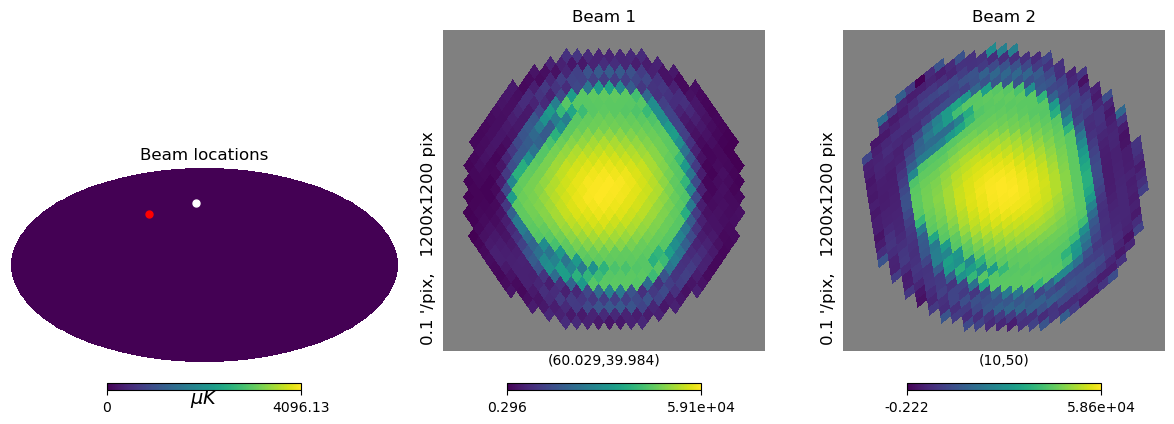

In [12]:
# TEST: precision of fast rotation to a random spot
map_beam2 = frot.beamrotation_test_opt(v1c, v2c, interpolator0, nside, angdistR)
x=fbeams.compare_beams(v1c, v2c, map_beam, map_beam2)

### Rotate beam back into itself

Results: 

maybe compare the two functions here [do later]

### Compare 2 rotated beams

# Test different interpolators: 

**FAILED ATTEMPTS:**

1.  

```python
from scipy.interpolate import griddata 
griddata(v1, beam0, v1_interp.T, method='nearest')
```

2. 

```python
from scipy.interpolate import NearestNDInterpolator
nearest_interp = NearestNDInterpolator(v1, beam0)
beam_interp_nearest = nearest_interp(v1_interp.T)
```